In [ ]:
from google.colab import drive
!pip install langchain -q
drive.mount('/content/drive')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.5 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
!pip install pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.0/276.0 kB 2.3 MB/s eta 0:00:00


In [ ]:
!pip install openai -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 1.1 MB/s eta 0:00:00


In [ ]:
!pip install tiktoken -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 11.0 MB/s eta 0:00:00


In [ ]:
from langchain.document_loaders import CSVLoader, PyPDFLoader, TextLoader, UnstructuredExcelLoader, Docx2txtLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceInstructEmbeddings
import os

DOCUMENT_MAP = {
    ".txt": TextLoader,
    ".md": TextLoader,
    ".py": TextLoader,
    ".pdf": PyPDFLoader,
    ".csv": CSVLoader,
    ".xls": UnstructuredExcelLoader,
    ".xlsx": UnstructuredExcelLoader,
    ".docx": Docx2txtLoader,
    ".doc": Docx2txtLoader,
}

def load_single_document(file_path: str):
    # Loads a single document from a file path
    file_extension = os.path.splitext(file_path)[1]
    loader_class = DOCUMENT_MAP.get(file_extension)
    if loader_class:
        loader = loader_class(file_path)
    else:
        raise ValueError("Document type is undefined")
    return loader.load()




In [ ]:
SOURCE_DIRECTORY = "/content/drive/MyDrive/Phantoms in the Brain.pdf"
pages = load_single_document(SOURCE_DIRECTORY)



In [ ]:
text = ""

for page in pages:
    text += page.page_content

text = text.replace('\t', ' ')

In [ ]:
import tiktoken

def num_tokens_from_string(string: str) -> int:
    encoding = tiktoken.get_encoding("cl100k_base")
    num_tokens = len(encoding.encode(string))
    return num_tokens

In [ ]:
from langchain.chat_models import ChatOpenAI
openai_api_key=""


# 2500 tokens per chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=150, length_function = num_tokens_from_string)
texts = text_splitter.create_documents([text])



In [ ]:
print(texts[1])

NameError: name 'texts' is not defined

In [ ]:
llm.get_num_tokens(texts[5].page_content)

1476

In [ ]:
# Loaders
from langchain.schema import Document

# Embedding Support
from langchain.vectorstores import FAISS
from langchain.embeddings import OpenAIEmbeddings


# Data Science
import numpy as np
from sklearn.cluster import KMeans

from langchain.chains.summarize import load_summarize_chain




In [ ]:
embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key)
vectors = embeddings.embed_documents([text.page_content for text in texts])


In [ ]:
len(vectors[1])

1536

In [ ]:
np.array(vectors[0][:5])

array([ 0.01794546,  0.0048562 ,  0.01468265,  0.00379855, -0.02069672])

In [ ]:
summary_chain = load_summarize_chain(llm=llm, chain_type='map_reduce')

In [ ]:
num_clusters = 15
# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=42).fit(vectors)

In [ ]:
kmeans.labels_

array([ 0,  0, 10,  0,  0,  7,  7, 11,  8,  8,  4,  8,  8,  4,  4,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  5, 14,  6, 12, 12, 12, 12,  6,  6,  3,
        3,  3,  3,  3,  3,  6,  6,  6,  7,  7,  7,  7,  7,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, 13, 13,  5,  5,  5,  5,  5,  2,  2,
        2,  2,  2,  2,  2, 13, 11, 11, 11,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 13,  0,  0,  0,  0, 14, 14, 14, 14,  0,  2,  2, 14, 13, 13],
      dtype=int32)

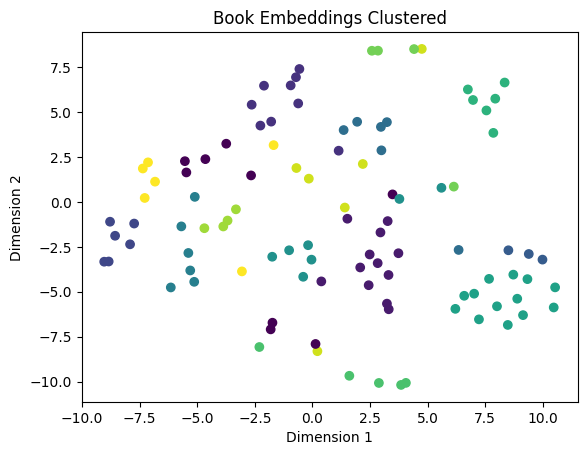

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

import warnings
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)

# Perform t-SNE and reduce to 2 dimensions
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

# Plot the reduced data
plt.scatter(reduced_data_tsne[:, 0], reduced_data_tsne[:, 1], c=kmeans.labels_)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Book Embeddings Clustered')
plt.show()

In [ ]:
 # Create an empty list that will hold your closest points
closest_indices = []

# Loop through the number of clusters you have
for i in range(num_clusters):

    # Get the list of distances from that particular cluster center
    distances = np.linalg.norm(vectors - kmeans.cluster_centers_[i], axis=1)

    # Find the list position of the closest one (using argmin to find the smallest distance)
    closest_index = np.argmin(distances)

    # Append that position to your closest indices list
    closest_indices.append(closest_index)

In [ ]:
selected_indices = sorted(closest_indices)
selected_indices

[13, 19, 29, 35, 40, 43, 54, 62, 70, 75, 78, 85, 89, 93, 101]

In [ ]:
from langchain import PromptTemplate
llm = ChatOpenAI(openai_api_key=openai_api_key, max_tokens=2400,model='gpt-3.5-turbo')
map_prompt = """
You will be given a single passage of a book. This section will be enclosed in triple backticks (```)
Your goal is to give a give bullet point summary of key facts of this section so that a reader will have a full understanding of this text.
Your response should be at least 10 bullet points and fully encompass what was said in the passage.

```{text}```
FULL SUMMARY:
"""
map_prompt_template = PromptTemplate(template=map_prompt, input_variables=["text"])


In [ ]:
map_chain = load_summarize_chain(llm=llm,
                             chain_type="stuff",
                             prompt=map_prompt_template)

selected_docs = [texts[doc] for doc in selected_indices]


In [ ]:
summary_list = []

for i, doc in enumerate(selected_docs):

    chunk_summary = map_chain.run([doc])

    summary_list.append(chunk_summary)

    print (f"Summary #{i} (chunk #{selected_indices[i]}) - Preview: {chunk_summary[:250]} \n")

Summary #0 (chunk #13) - Preview: - Brain maps are not static, but in a state of dynamic equilibrium with adjacent neurons.
- Phantom limb sensations are not imaginary, but have a logical explanation in brain remapping.
- Phantom sensations can occur in body parts adjacent to the los 

Summary #1 (chunk #19) - Preview: - Philip practiced with a mirror box to receive visual feedback and potentially restore movement in his phantom limb.
- After using the mirror box for a week, Philip still couldn't move his arm without it.
- Eventually, Philip called the doctor excit 

Summary #2 (chunk #29) - Preview: - Blindsight is the ability to correctly guess the presence of an object that cannot be consciously perceived.
- The division of labor between the two visual pathways (orienting pathway and newer pathway) can explain blindsight.
- The orienting pathw 

Summary #3 (chunk #35) - Preview: - When aiming the blind spot at the corner of a square, the corner disappears or looks "bitten off" or sm

In [ ]:
summaries = "\n".join(summary_list)

# Convert it back to a document
summaries = Document(page_content=summaries)

print (f"Your total summary has {llm.get_num_tokens(summaries.page_content)} tokens")
summaries.page_content

Your total summary has 3611 tokens


'- Brain maps are not static, but in a state of dynamic equilibrium with adjacent neurons.\n- Phantom limb sensations are not imaginary, but have a logical explanation in brain remapping.\n- Phantom sensations can occur in body parts adjacent to the lost limb.\n- The phenomenon of remapping can explain strange sensations in phantom limbs during sexual activity.\n- The foot and genitals are mapped next to each other in the brain.\n- Patients who have lost a leg may experience sensations in the phantom leg when stimulated in the genitals.\n- The size of the phantom foot may increase due to the transfer of erotic sensations from the genitals.\n- Foot fetishes may be explained by the proximity of the foot and genitalia in the brain.\n- Amputations of the penis can result in phantom erections and potentially pleasurable sensations in the phantom penis when the feet are stimulated.\n- Mastectomy patients may experience phantom breasts, with sensations in the phantom nipple when adjacent area

In [ ]:
for i, doc in enumerate(summary_list):
    print (f"Summary #{i} (chunk #{selected_indices[i]}) - Preview: {doc[:]} \n")

In [ ]:
llm4 = ChatOpenAI(temperature=0,
                 openai_api_key=openai_api_key,
                 max_tokens=3000,
                 model='gpt-4',
                 request_timeout=120,
                )
combine_prompt = """


```{text}```

You will be given a series of bullet points from body of text. The summaries will be enclosed in triple backticks (```)
Your goal is to give a summary while retaining as much as detail as possible about the text. Make sure to remember
The reader should be able to grasp what happened in the text.

VERBOSE SUMMARY:
"""
combine_prompt_template = PromptTemplate(template=combine_prompt, input_variables=["text"])
reduce_chain = load_summarize_chain(llm=llm4,
                             chain_type="stuff",
                             prompt=combine_prompt_template,
#                              verbose=True # Set this to true if you want to see the inner workings
                                   )
output = reduce_chain.run([summaries])


In [ ]:
from textwrap import wrap
long_str = output
lines = wrap(long_str, 50) #wrap outputs a list of lines
print('\n'.join(lines))    #so join 'em with newline



The text discusses various aspects of brain
science, starting with the concept of brain maps
and their dynamic nature. It explains the
phenomenon of phantom limb sensations and how they
can be understood through the process of brain
remapping. The text also explores the relationship
between the brain's mapping of the foot and
genitals, suggesting that this proximity could
explain foot fetishes and certain sensations
experienced by amputees.  The text then delves
into the concept of blindsight, the ability to
perceive objects without conscious awareness, and
the division of labor between the two visual
pathways in the brain. It also discusses the
phenomenon of neglect, where patients fail to pay
attention to one side of their visual field, and
denial, where patients deny their disabilities.
The text also explores the intriguing case of
Capgras' syndrome, where individuals can recognize
faces but do not experience any emotional response
towards them. It suggests that this could be due
to

In [ ]:
from langchain.chains import RetrievalQA
from langchain.llms import OpenAI
from langchain.document_loaders import WebBaseLoader

loader = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/")
data = loader.load()


In [ ]:
db = FAISS.from_documents(texts, embeddings)
query = "What is homonculus"
docs = db.similarity_search(query)

NameError: name 'FAISS' is not defined

In [ ]:
print("""Your total summary has 3611 tokens
- Brain maps are not static, but in a state of dynamic equilibrium with adjacent neurons.\n- Phantom limb sensations are not imaginary, but have a logical explanation in brain remapping.\n- Phantom sensations can occur in body parts adjacent to the lost limb.\n- The phenomenon of remapping can explain strange sensations in phantom limbs during sexual activity.\n- The foot and genitals are mapped next to each other in the brain.\n- Patients who have lost a leg may experience sensations in the phantom leg when stimulated in the genitals.\n- The size of the phantom foot may increase due to the transfer of erotic sensations from the genitals.\n- Foot fetishes may be explained by the proximity of the foot and genitalia in the brain.\n- Amputations of the penis can result in phantom erections and potentially pleasurable sensations in the phantom penis when the feet are stimulated.\n- Mastectomy patients may experience phantom breasts, with sensations in the phantom nipple when adjacent areas on the chest are stimulated.\n- Some mastectomy patients may also experience tingling, erotic sensations in their phantom nipples when their earlobes are stimulated.\n- Philip practiced with a mirror box to receive visual feedback and potentially restore movement in his phantom limb.\n- After using the mirror box for a week, Philip still couldn\'t move his arm without it.\n- Eventually, Philip called the doctor excitedly to say that his phantom arm was gone, but he still had phantom fingers and palm.\n- Philip no longer felt pain in his phantom elbow and was not bothered by the disappearance of his phantom arm.\n- Movements and paralysis of phantom limbs are difficult to explain, as well as the agonizing pain that many patients experience.\n- The pain could be caused by scar tissue or neuromas in the stump.\n- Phantom pain sometimes disappears temporarily after surgically removing neuromas but often returns.\n- Remapping, the process of the brain adjusting to the missing limb, could also contribute to phantom pain.\n- Abnormal remapping could cause pain by mistakenly connecting touch input to pain centers.\n- Abnormal remapping could also disrupt volume control mechanisms and create chaotic touch synapse activity, leading to pain.\n- Some patients may also experience pain memory, where the pain felt prior to amputation persists.\n- Blindsight is the ability to correctly guess the presence of an object that cannot be consciously perceived.\n- The division of labor between the two visual pathways (orienting pathway and newer pathway) can explain blindsight.\n- The orienting pathway, which is phylogenetically primitive, remains intact even if the primary visual cortex is damaged.\n- The spot of light in the blind region can still be transmitted through the superior colliculus to higher brain centers, guiding behavior.\n- Conscious awareness ("I see this") is attributed to the new pathway, while the old pathway can still use visual input for behavior without conscious awareness.\n- The perception story is more complicated, as information in the new pathway diverges into the "where" pathway and the "what" pathway.\n- The "where" pathway specializes in spatial vision and visually guided movements, while the "what" pathway is concerned with object identification.\n- The majority of visual areas are located in the "what" pathway, highlighting its importance in object recognition.\n- Face cells exist in the "what" pathway and play a critical role in recognizing faces and evoking emotions.\n- If the "what" pathway is selectively obliterated, objects would be unrecognizable and lack emotional or semantic associations.\n- Monkeys with surgically removed temporal lobes (containing the "what" pathway) struggle to recognize objects, including prey and mates.\n- When aiming the blind spot at the corner of a square, the corner disappears or looks "bitten off" or smudged.\n- The neural machinery that allows completion across the blind spot cannot deal with corners.\n- Aiming the blind spot at the center of a bicycle wheel with radiating spokes results in the spokes converging into a vortex at the center of the blind spot.\n- Some things can be completed across the blind spot, while others cannot.\n- Many people are curious about the inner workings of their visual pathways and have experimented with their blind spots.\n- People can use their blind spots creatively in art.\n- Filling in missing portions of the visual field is a natural process for those with a blind spot.\n- Patients with a larger permanent blind spot provide an opportunity to study the brain\'s ability to supply missing information.\n- Josh is a patient with a large permanent blind spot caused by an industrial accident.\n- Josh\'s deficit is not noticeable unless he scrutinizes his visual field, as he is able to fill in the missing information.\n- The speaker is talking to Larry, who experiences hallucinations.\n- Larry sees a monkey sitting on the speaker\'s lap, even though there is no monkey there.\n- Larry\'s hallucinations are vivid and fade after a few seconds or minutes.\n- The hallucinations often blend well into the rest of the scene, but Larry knows they are not real.\n- Larry\'s hallucinations look more real than real objects and have vibrant colors.\n- Larry is more concerned about being blind than about seeing hallucinations.\n- Larry\'s hallucinations can be completely new images or ordinary objects.\n- The speaker then meets another patient named Nancy who sees cartoons in her scotoma.\n- Nancy\'s cartoons are line drawings filled in with uniform color, similar to comic books.\n- Nancy\'s cartoons are stationary and lack depth, shading, and curvature.\n- The current understanding of visual perception needs to be revised, as there are feedback pathways and information flow that can diverge, reinforce, or travel in opposite directions.\n- Ellen neglects the left side of her body and objects on the left side of her visual field\n- Sam is concerned about his mother\'s condition and wonders if there is a way to help her\n- Neglect is a common problem with implications for understanding how the brain creates a spatial representation of the world\n- Immanuel Kant was obsessed with the concepts of space and time and would be fascinated by Ellen\'s symptoms\n- The visual information from the eyes is processed in the primary visual cortex and relayed to the temporal and parietal lobes\n- The temporal lobes are responsible for recognizing objects and the parietal lobes are responsible for discerning the spatial layout of the world\n- Neglect patients with damage to the right parietal lobe do not pay attention to the left side of space\n- Neglect arises from a failure to pay attention, but the underlying neural mechanisms are not well understood\n- Attention requires the participation of many regions of the brain, including the reticular activating system, limbic system, and frontal lobes\n- Neglect occurs primarily after injury to the right parietal lobe, potentially due to the right hemisphere\'s broad "searchlight" of attention.\n- The author\'s "speculative" ideas on hemispheric specialization are supported by the fact that discrepancies activate the right hemisphere.\n- Patients with denial do not only deny paralysis, but can also deny other disabilities.\n- The location of brain lesions correlates with the extent and type of denial experienced by patients.\n- Denial can be self-protective and can manifest as a distraction from more serious conditions.\n- Denial can be a displacement mechanism to avoid facing impending death.\n- Delusions can be extreme, such as a man who believed medical students were putting a cadaver\'s arm in his bed.\n- Denial is deeply anchored in the psyche of denial patients, but the information about their paralysis is not available to their conscious mind.\n- An experiment involving irrigation of the left ear with cold water temporarily reversed anosognosia in a patient with a right parietal lesion.\n- The author was inspired by this experiment and decided to try it on a patient with anosognosia.\n- The purpose was to confirm the observation and ask specific questions to test the patient\'s memory and understanding of their denial.\n- Capgras\' syndrome is a condition where individuals can recognize faces but do not experience any emotional response towards them.\n- The temporal lobes of the brain contain regions that specialize in face and object recognition.\n- Face recognition areas in the brain relay information to the limbic system, which helps generate emotional responses to particular faces.\n- Arthur\'s behavior may be due to a disconnection between the face recognition region of his brain and his amygdala, which processes emotions.\n- Arthur recognizes his parents but does not feel any emotions when looking at their faces, leading him to believe they are impostors.\n- The limbic system is responsible for emotions and consists of interconnected cell clusters and fiber tracts.\n- Psychologists have found a simple way to measure emotional responses to faces by measuring changes in the electrical resistance of the skin.\n- Arthur\'s lack of emotional response can be tested by measuring his galvanic skin response (GSR) when looking at pictures of his parents.\n- The GSR measures changes in skin conductance, which indicates emotional arousal.\n- Arthur\'s lack of emotional response was confirmed through testing, as his galvanic skin response did not change when looking at pictures of his parents compared to control subjects.\n- Emotional changes alone cannot fully explain religious preoccupation\n- Connections between sensory centers and the amygdala can result in increased communication between brain structures, leading to deep significance being attributed to every object and event\n- There is speculation about the existence of specialized neural circuitry that mediates religious experience\n- Evolutionary psychology suggests that many human traits and propensities, including religious beliefs, may have been selected for their adaptive value\n- Men tend to be more polygamous and promiscuous, while women tend to be more monogamous, which can be explained by evolutionary strategies to disseminate genes and invest in offspring\n- Universal traits, like cooking, do not necessarily have a genetic basis, but are likely an offshoot of other skills and characteristics\n- The origin of religion may be explained by the human tendency to seek authority figures, encouraging conformist behavior and contributing to social stability\n- Certain parts of the temporal lobe play a more direct role in religious experiences than any other part of the brain\n- Personal experiences of Dr. Persinger suggest that these changes can occur in individuals without epilepsy\n- It is not up to physicians to label mystical experiences as normal or abnormal, as rarity does not necessarily equate to abnormality.\n- Ramanujan was a gifted mathematician who made several new theorems before the age of twenty-two.\n- G.H. Hardy, a top number theorist, initially thought Ramanujan was a crackpot but later realized his genius.\n- Ramanujan\'s mathematical skills were exceptional and considered almost supernatural.\n- General intelligence and mathematical ability are not directly correlated, as Ramanujan\'s abilities were far beyond what would be expected based on intelligence alone.\n- Ramanujan believed that the equations he discovered were whispered to him in dreams by the village deity.\n- One explanation for genius is that it results from fortuitous combinations of different mental traits influenced by genes.\n- Autistic savants like Nadia and Tom possess unique talents despite their abysmal general intelligence, which challenges the fortuitous combinations explanation.\n- The left angular gyrus, a region in the brain, is crucial for mathematical computation and may play a role in savant abilities.\n- Savants may have undergone brain remapping due to early brain damage, resulting in unusual rewiring and increased abilities in specific areas.\n- An enlarged left angular gyrus or right angular gyrus could lead to exceptional mathematical or artistic abilities, respectively.\n- The biological function of evolved traits, such as yawning, laughing, crying, or dancing, is vital to understanding their purpose.\n- Evolutionary psychology argues that many aspects of human behavior are mediated by specialized modules shaped by natural selection.\n- Pleistocene ancestors evolved brain solutions to everyday problems, such as recognizing kin, seeking healthy sexual partners, and avoiding foul-smelling food.\n- Disgust for feces is likely hard-wired in the brain due to the potential presence of infectious bacteria, eggs, and parasites.\n- Evolutionary psychology is a controversial field that polarizes scientists, with some supporting it and others vehemently against it.\n- The evolutionary perspective is essential for understanding certain traits, like laughter, and the existence of a specialized laughter circuit.\n- However, for other traits, the evolutionary perspective may not be useful, such as for cooking.\n- Evolutionary psychology explanations can be untestable and may blur the line between fact and fiction.\n- The author satirically wrote an essay to test the limits of evolutionary explanations for human behavior, but some colleagues found it plausible instead of a spoof.\n- Laughter is a behavior that is difficult to explain from an evolutionary perspective, but there may be a deep structure underlying all types of humor.\n- Empathy with a pregnant woman may release prolactin in her husband\'s brain, causing changes in him.\n- Pseudocyesis is an example of mind-body medicine, suggesting that the mind can influence physical conditions.\n- Hypnotizing someone can eliminate warts, potentially indicating a way to treat other conditions like cancer.\n- Two possibilities for eliminating tumors through hypnosis include the autonomic nervous system constricting blood vessels or kickstarting the immune system.\n- The immune system can be influenced by perceptual cues, such as experiencing allergic responses from merely seeing a rose.\n- Conditioning can potentially be used to neutralize asthma attacks by associating relief with a specific image or object.\n- It is unknown how selective conditioning processes can be or if they can be used to stimulate the immune system.\n- The potential implications of conditioning for clinical medicine are significant.\n- An accidental discovery showed that mice developed aversions and fell ill when given a nausea-inducing drug along with saccharin.\n- This discovery suggests that the mind can influence the body\'s response to certain substances.\n- The problem of consciousness has been a major topic of discussion in both Eastern and Western philosophy.\n- Consciousness is a fascinating but elusive phenomenon that is difficult to define or explain.\n- Most people agree that consciousness arises in the brain, specifically in certain specialized brain circuits.\n- The circuits that embody consciousness are mainly located in the temporal lobes and frontal lobes of the brain.\n- These specialized brain structures must fulfill three important criteria, known as the "three laws of qualia," in order to generate consciousness.\n- The central mystery of consciousness is the existence of two parallel descriptions of the universe: the first-person account and the third-person account.\n- The need to reconcile these two accounts is the single most important unsolved problem in science.\n- Indian mystics and sages argue that the separation between self and nonself is an illusion and that we are all one with the cosmos.\n- The problem of subjective sensation, or qualia, is how the neurons in the brain generate the subjective world of sensations.\n- The author presents a thought experiment to illustrate the problem of qualia and the difficulty of understanding subjective experiences.\n- The passage discusses the difference between perceptions that have qualia (subjective experiences) and those that do not.\n- Qualia-laden perceptions are irrevocable and cannot be changed by higher brain centers.\n- In contrast, perceptions that lack qualia are flexible and can be changed or imagined in different ways.\n- The passage uses examples of a yellow doughnut and an occluded finger to illustrate the difference between qualia-laden and non-qualia-laden perceptions.\n- Qualia-laden perceptions are tamper-resistant and cannot be easily changed or altered.\n- The passage also mentions that qualia must be irrevocable, but this alone is not enough to explain their presence.\n- It suggests that qualia-laden perceptions have the luxury of choice and can evoke a range of associations or thoughts.\n- The passage identifies three important features of qualia: irrevocability on the input side, flexibility on the output side, and the ability to hold the representation in memory.\n- It mentions that holding information in a buffer or immediate memory is not enough to generate qualia, as biological systems can have other reasons for doing so.\n- The passage references a previous chapter regarding the connection between qualia and memory, using the example of a woman with blindsight.\n- Self-deception is a result of evolutionary strategies and is a matter of compromise.\n- It is difficult to test the idea that self-deception evolved in a social context, but patients with denial syndrome can provide some insights.\n- The author wonders if a patient with denial syndrome would deny their paralysis to themselves and if the delusion is amplified when others are present.\n- The author questions whether a patient with denial syndrome would show a skin response when presented with the word "paralysis" and if a normal child would show a skin change when confabulating.\n- The author also ponders if a neurologist with denial syndrome would continue to lecture without being aware of their own condition.\n- The nature of the self is described as the greatest scientific and philosophical riddle.\n- The passage includes a quote from William Shakespeare\'s play "The Tempest" about the transient nature of life.\n- Neuroscientists have made significant progress in understanding the nervous system and how mental life emerges from the brain.\n- The idea that our sense of having a nonmaterial soul is an illusion is ennobling and liberating.\n- The author highlights the humility that comes from realizing our place in the universe and quotes cosmologist Paul Davies on the mystery of human rationality and connection to the cosmos.\n- The existence of mind in the universe is seen as a fact of fundamental significance, suggesting that we are meant to be here.\n- Brain science alone may not answer the question of our purpose, but the ability to ask the question is puzzling.""")

Your total summary has 3611 tokens
- Brain maps are not static, but in a state of dynamic equilibrium with adjacent neurons.
- Phantom limb sensations are not imaginary, but have a logical explanation in brain remapping.
- Phantom sensations can occur in body parts adjacent to the lost limb.
- The phenomenon of remapping can explain strange sensations in phantom limbs during sexual activity.
- The foot and genitals are mapped next to each other in the brain.
- Patients who have lost a leg may experience sensations in the phantom leg when stimulated in the genitals.
- The size of the phantom foot may increase due to the transfer of erotic sensations from the genitals.
- Foot fetishes may be explained by the proximity of the foot and genitalia in the brain.
- Amputations of the penis can result in phantom erections and potentially pleasurable sensations in the phantom penis when the feet are stimulated.
- Mastectomy patients may experience phantom breasts, with sensations in the phantom 

In [ ]:
# from langchain.chains.llm import LLMChain
# from langchain.prompts import PromptTemplate
# from langchain.chains.combine_documents.stuff import StuffDocumentsChain
# from langchain.chains.mapreduce import MapReduceChain
# from langchain.text_splitter import CharacterTextSplitter
# from langchain.chains import ReduceDocumentsChain, MapReduceDocumentsChain

In [ ]:
# # Reduce
# reduce_template = """The following is set of summaries:
# {doc_summaries}
# Take these and distill it into a final, consolidated summary of the main themes.
# Helpful Answer:"""
# reduce_prompt = PromptTemplate.from_template(reduce_template)
# reduce_chain = LLMChain(llm=llm, prompt=reduce_prompt)

# # Takes a list of documents, combines them into a single string, and passes this to an LLMChain
# combine_documents_chain = StuffDocumentsChain(
#     llm_chain=reduce_chain, document_variable_name="doc_summaries"
# )

# # Combines and iteravely reduces the mapped documents
# reduce_documents_chain = ReduceDocumentsChain(
#     # This is final chain that is called.
#     combine_documents_chain=combine_documents_chain,
#     # If documents exceed context for `StuffDocumentsChain`
#     collapse_documents_chain=combine_documents_chain,
#     # The maximum number of tokens to group documents into.
#     token_max=4000,

# # Combining documents by mapping a chain over them, then combining results
# map_reduce_chain = MapReduceDocumentsChain(
#     # Map chain
#     llm_chain=map_chain,
#     # Reduce chain
#     reduce_documents_chain=reduce_documents_chain,
#     # The variable name in the llm_chain to put the documents in
#     document_variable_name="docs",
#     # Return the results of the map steps in the output
#     return_intermediate_steps=False,
# )

# text_splitter = CharacterTextSplitter.from_tiktoken_encoder(
#     chunk_size=1000, chunk_overlap=0
# )
# split_docs = text_splitter.split_documents(docs)